In [11]:
!pip install matplotlib

In [12]:
!pip install pandas

In [13]:
!pip install Unidecode

In [14]:
import re
import nltk

import pandas as pd
import numpy as np

from string import punctuation
from unidecode import unidecode
from nltk.corpus import stopwords

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [15]:
def plot_graph(label, data):
  plt.bar(label, data, color='#5d52b0')

  for i, value in enumerate(data):
      plt.text(i, value, str(value), ha='center', va='bottom')

  plt.show()


import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

def plot_graph2(label, data, title=""):
    plt.rcParams.update({
        "font.size": 12,
        "font.family": "serif"
    })

    fig, ax = plt.subplots(figsize=(8, 5))

    for i, value in enumerate(data):
        bar = FancyBboxPatch(
            (i - 0.35, 0),
            0.7,
            value,
            boxstyle="round,pad=0.02,rounding_size=0.08",
            facecolor="#4C72B0",   # azul acadêmico
            edgecolor="#2A3F8F",   # borda mais forte
            linewidth=1.5
        )
        ax.add_patch(bar)

        ax.text(
            i, value + max(data)*0.01,
            f"{value}",
            ha='center',
            va='bottom',
            fontsize=11
        )

    # Configuração dos eixos
    ax.set_xticks(range(len(label)))
    ax.set_xticklabels(label)

    ax.set_ylabel("Quantidade")
    ax.set_title(title, fontsize=14, pad=15)

    # Remover bordas desnecessárias
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Grid leve (horizontal)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    ax.xaxis.grid(False)

    ax.set_xlim(-0.5, len(label) - 0.5)
    ax.set_ylim(0, max(data) * 1.15)

    plt.tight_layout()
    plt.show()

In [16]:
def load_data():
  url = 'https://docs.google.com/spreadsheets/d/1MaxiOZdpysqqEgBKXW1ISOGVAMOirpgm/edit?usp=sharing&ouid=117999606608884179014&rtpof=true&sd=true'
  file_id = url.split('/')[-2]
  read_url='https://drive.google.com/uc?id=' + file_id

  data_set = pd.read_excel(read_url, index_col=False)

  condition = [
      data_set["rotulo_humano"] == "sem_sintoma", # 0
      data_set["rotulo_humano"] == "sintoma" # 1
  ]

  values = [0, 1]

  data_set["classification"] = np.select(condition, values)

  return data_set

In [17]:
nltk.download('rslp')
nltk.download('stopwords')
stopwords_list = stopwords.words('portuguese')

def balancing(data):
  data_process = data.copy()

  old_texts = data_process["Texto"]
  new_texts = []

  for text in old_texts:
    text = str(text).lower()
    text = re.sub('@[^\s]+', '', text)
    text = unidecode(text)
    text = re.sub('<[^<]+?>','', text)
    text = ''.join(c for c in text if not c.isdigit())
    text = re.sub('((www\.[^\s]+)|(https?://[^\s]+)|(http?://[^\s]+))', '', text)
    text = ''.join(c for c in text if c not in punctuation)
    text = ' '.join([word for word in text.split() if word not in stopwords_list])
    text = ''.join(text.replace("\"", ""))
    text = ''.join(text.replace("'", ""))
    new_texts.append(text)

  data_process["Texto"] = new_texts

  return data_process

[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Package rslp is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:
def unbalanced_distribution():
  data = load_data()
  counts = data['classification'].value_counts()

  label = ['Com sintoma', 'Sem sintoma']
  values = [counts.get(0, 0), counts.get(1, 0)]

  plot_graph2(label, values)


def balanced_distribution():
  data = load_data()

  data = balancing(data)

  counts = data['classification'].value_counts()

  label = ['Com sintoma', 'Sem sintoma']
  values = [counts.get(0, 0), counts.get(1, 0)]

  plot_graph2(label, values)


In [19]:
def sample_sentences_by_class(df, class_column, n=10, random_state=None):
    sampled_df = (
        df.groupby(class_column, group_keys=False)
          .apply(lambda x: x.sample(n=min(len(x), n), random_state=random_state))
          .reset_index(drop=True)
    )

    return sampled_df.to_excel('exemplos.xlsx')

Distribuição antes do balanceamento


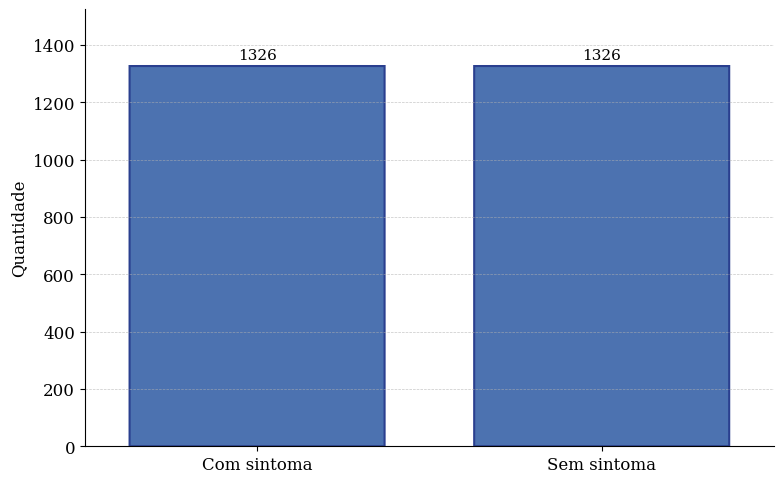


Distribuição após o balanceamento


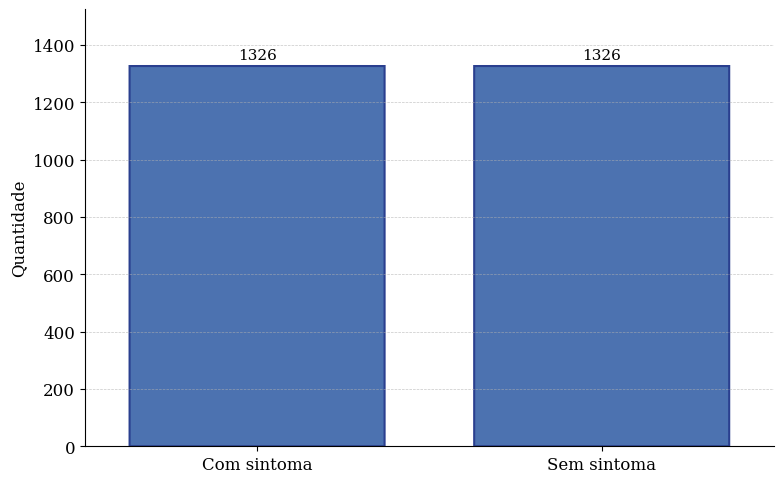

None


In [20]:
if __name__ == '__main__':
  print("Distribuição antes do balanceamento")
  unbalanced_distribution()

  print()

  print("Distribuição após o balanceamento")
  balanced_distribution()

  print(sample_sentences_by_class(load_data(), 'classification'))